------------------
```markdown
# Copyright © 2025 Meysam Goodarzi
This notebook is licensed under CC BY-NC 4.0 with the following amendments:
- Individuals may use, share, and adapt this material for non-commercial purposes with attribution.
- Institutions/Companies must obtain written consent to use this material, except for nonprofits.
- Commercial use is prohibited without permission.  
Contact: analytica@meysam-goodarzi.com
```
------------------------------
❗❗❗ **IMPORTANT**❗❗❗ **Create a copy of this notebook**

In order to work with this Google Colab you need to create a copy of it. Please **DO NOT** provide your answers here. Instead, work on the copy version. To make a copy:

**Click on: File -> save a copy in drive**

Have you successfully created the copy? if yes, there must be a new tab opened in your browser. Now move to the copy and start from there!

----------------------------------------------


# Bayesian Linear Models with PyMC

## Learning Objectives

By the end of this notebook, you will be able to:
1. Build Bayesian linear regression models with PyMC
2. Interpret posterior distributions for regression parameters
3. Understand and diagnose MCMC sampling
4. Compare models using information criteria
5. Make predictions with uncertainty quantification

In [1]:
import pymc as pm
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

# Set random seed for reproducibility
np.random.seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
az.style.use("arviz-darkgrid")

## Linear Regression Model
We want to model the relationship between a predictor variable $X$ and an outcome variable $Y$.

$$Y_i = \alpha + \beta X_i + \epsilon_i$$

Where:
- $\alpha$ = intercept
- $\beta$ = slope
- $\epsilon_i \sim \text{Normal}(0, \sigma)$ = noise/error

### Bayesian Formulation

Bayesian statistics treats parameters as random variables. Therefore, we need priors for all parameters:
- **Prior on intercept**: $\alpha \sim \text{Normal}(\mu_{\alpha}, \sigma_{\alpha})$
- **Prior on slope**: $\beta \sim \text{Normal}(\mu_{\beta}, \sigma_{\beta})$
- **Prior on noise**: $\sigma \sim \text{HalfNormal}(\sigma_0)$
- **Likelihood**: $Y_i | \alpha, \beta, \sigma \sim \text{Normal}(\alpha + \beta X_i, \sigma)$

#### Example

Let's model the relationship between height and weight using simulated data.

In [2]:
# Generate synthetic data: Height (cm) vs Weight (kg)
np.random.seed(42)
n = 100

# True parameters
true_alpha = -80  # intercept
true_beta = 0.9   # slope
true_sigma = 5    # noise

# Generate height data
height = np.random.uniform(150, 190, n)

# Generate weight data with noise
weight = true_alpha + true_beta * height + np.random.normal(0, true_sigma, n)

# Create a DataFrame
df = pd.DataFrame({'height': height, 'weight': weight})
print(df.head(3))
print(f"\nData shape: {df.shape}")

       height     weight
0  164.981605  68.918680
1  188.028572  87.730678
2  179.279758  81.810586

Data shape: (100, 2)


We can also visualize the data for better understanding

/tmp/ipykernel_1287/1012682094.py:8: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


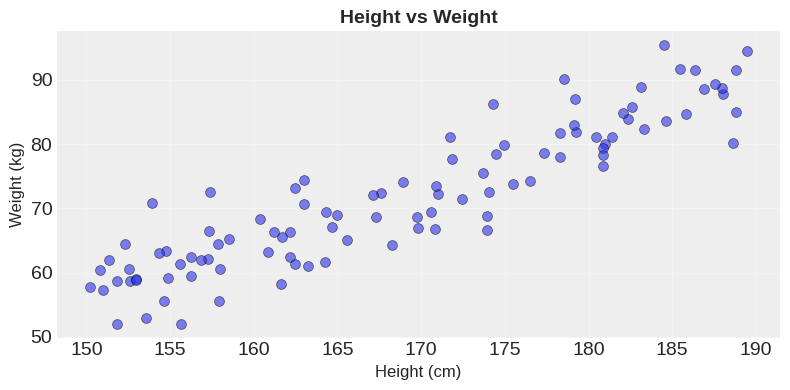

Correlation: 0.912


In [3]:
# Visualize the data
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(height, weight, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax.set_xlabel('Height (cm)', fontsize=12)
ax.set_ylabel('Weight (kg)', fontsize=12)
ax.set_title('Height vs Weight', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Correlation: {np.corrcoef(height, weight)[0,1]:.3f}")

##### Bayesian Linear Model in PyMC
Building regression models in PyMC concerns
1. Assuming the priors for each variable
1. Constructing the likelihood function
1. Performing the sampling

In [4]:
# Standardize predictors (recommended for better sampling)
height_mean = height.mean()
height_std = height.std()
height_std_scaled = (height - height_mean) / height_std

with pm.Model() as linear_model:
    # Priors
    alpha = pm.Normal('alpha', mu=0, sigma=20)  # Intercept
    beta = pm.Normal('beta', mu=0, sigma=10)     # Slope
    sigma = pm.HalfNormal('sigma', sigma=10)     # Noise

    # Linear model
    mu = alpha + beta * height_std_scaled

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=weight)

    # Sample from posterior
    trace_linear = pm.sample(2000, tune=1000, chains=3, random_seed=42, return_inferencedata=True)

print("\nSampling complete!")

Output()


Sampling complete!


##### Posterior Analysis
After sampling, we can visualize the posterior distribution of each random variable.

/tmp/ipykernel_1287/2402311906.py:6: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


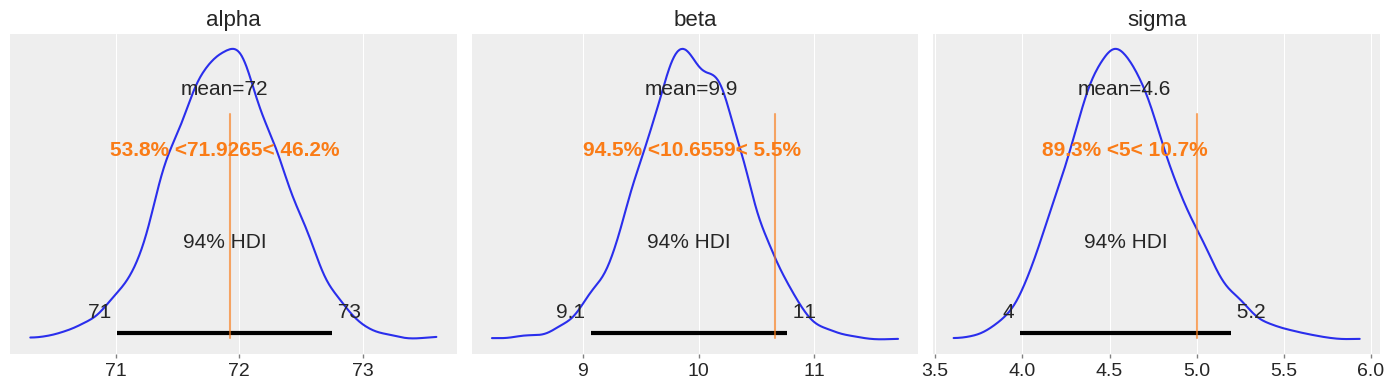


Posterior Summary:
         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
alpha  71.882  0.461  71.013   72.754      0.005    0.006    9393.0    4871.0   
beta    9.939  0.451   9.069   10.765      0.005    0.006    9288.0    4518.0   
sigma   4.586  0.323   3.987    5.197      0.004    0.004    7313.0    4340.0   

       r_hat  
alpha    1.0  
beta     1.0  
sigma    1.0  


In [5]:
# Plot posterior distributions
az.plot_posterior(trace_linear, var_names=['alpha', 'beta', 'sigma'],
                  ref_val=[true_alpha + true_beta * height_mean,
                          true_beta * height_std, true_sigma],
                  figsize=(14, 4))
plt.tight_layout()
plt.show()

# Summary statistics
print("\nPosterior Summary:")
print(az.summary(trace_linear, var_names=['alpha', 'beta', 'sigma']))

##### Interpreting Results

**Note on standardization**: Since we standardized height, we need to interpret parameters carefully:
- `alpha` is the expected weight when height is at its mean
- `beta` tells us the change in weight for one standard deviation change in height
- To get the original scale slope: $\beta_{\text{original}} = \beta / \sigma_{\text{height}}$

In [6]:
# Convert back to original scale
beta_samples = trace_linear.posterior['beta'].values.flatten()
beta_original_scale = beta_samples / height_std

print(f"Original scale slope estimate: {beta_original_scale.mean():.3f}")
print(f"True slope: {true_beta}")
print(f"\n95% Credible Interval: [{np.percentile(beta_original_scale, 2.5):.3f}, {np.percentile(beta_original_scale, 97.5):.3f}]")

Original scale slope estimate: 0.839
True slope: 0.9

95% Credible Interval: [0.764, 0.914]


##### Visualizing the Fit

/tmp/ipykernel_1287/3469528083.py:32: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


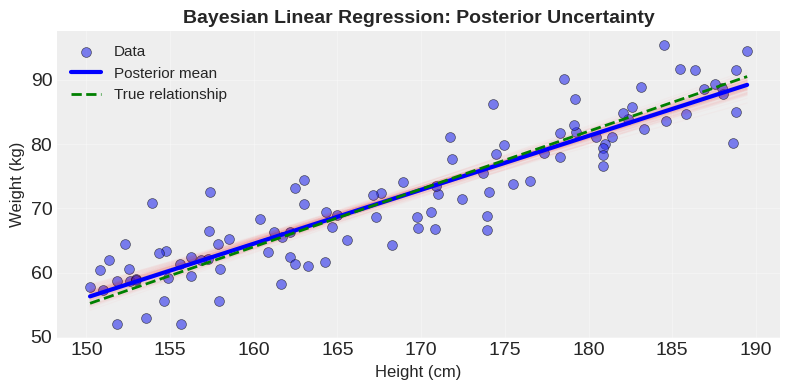

Red band: Uncertainty in the regression line (epistemic uncertainty)
This reflects our uncertainty about the true parameters α and β


In [7]:
# Extract posterior samples
alpha_samples = trace_linear.posterior['alpha'].values.flatten()
beta_samples = trace_linear.posterior['beta'].values.flatten()

# Plot data with uncertainty
fig, ax = plt.subplots(figsize=(8, 4))

# Plot raw data
ax.scatter(height, weight, alpha=0.6, s=50, edgecolors='black', linewidth=0.5, label='Data')

# Plot posterior regression lines (sample 100 lines)
x_plot = np.linspace(height.min(), height.max(), 100)
x_plot_std = (x_plot - height_mean) / height_std

for i in np.random.choice(len(alpha_samples), 100):
    y_plot = alpha_samples[i] + beta_samples[i] * x_plot_std
    ax.plot(x_plot, y_plot, 'r-', alpha=0.02, linewidth=1)

# Plot mean regression line
y_mean = alpha_samples.mean() + beta_samples.mean() * x_plot_std
ax.plot(x_plot, y_mean, 'b-', linewidth=3, label='Posterior mean', zorder=5)

# Plot true line
y_true = true_alpha + true_beta * x_plot
ax.plot(x_plot, y_true, 'g--', linewidth=2, label='True relationship', zorder=5)

ax.set_xlabel('Height (cm)', fontsize=12)
ax.set_ylabel('Weight (kg)', fontsize=12)
ax.set_title('Bayesian Linear Regression: Posterior Uncertainty', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Red band: Uncertainty in the regression line (epistemic uncertainty)")
print("This reflects our uncertainty about the true parameters α and β")

## Multiple Linear Regression

Now we extend to multiple predictors:

$$Y_i = \alpha + \beta_1 X_{i1} + \beta_2 X_{i2} + ... + \beta_p X_{ip} + \epsilon_i$$

In matrix form:
$$Y = \alpha + X\boldsymbol{\beta} + \boldsymbol{\epsilon}$$

### Example

Let's model house prices based on area, number of bedrooms, and age.

In [8]:
# Generate synthetic housing data
np.random.seed(42)
n_houses = 150

# Features
area = np.random.uniform(800, 3000, n_houses)        # sq ft
bedrooms = np.random.randint(1, 6, n_houses)         # number of bedrooms
age = np.random.uniform(0, 50, n_houses)             # years

# True parameters
true_intercept = 50000
true_beta_area = 150
true_beta_bedrooms = 20000
true_beta_age = -500
true_sigma_price = 30000

# Generate prices
price = (true_intercept +
         true_beta_area * area +
         true_beta_bedrooms * bedrooms +
         true_beta_age * age +
         np.random.normal(0, true_sigma_price, n_houses))

# Create DataFrame
df_houses = pd.DataFrame({
    'area': area,
    'bedrooms': bedrooms,
    'age': age,
    'price': price
})

print(df_houses.head())
print(f"\nCorrelation with price:")
print(df_houses.corr()['price'].sort_values(ascending=False))

          area  bedrooms        age          price
0  1623.988261         1  31.394721  352310.876122
1  2891.571474         1   9.713698  511016.359131
2  2410.386672         3   3.547046  472486.655482
3  2117.048665         2  19.839191  400119.617179
4  1143.241009         5   2.538427  312464.405995

Correlation with price:
price       1.000000
area        0.927651
bedrooms    0.263810
age        -0.109223
Name: price, dtype: float64


/tmp/ipykernel_1287/2680473392.py:22: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


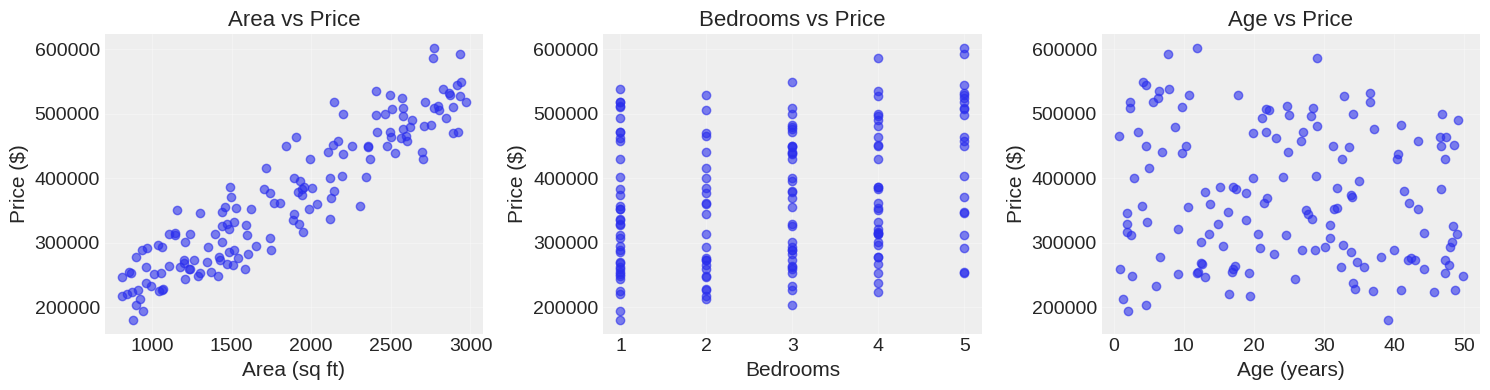

In [9]:
# Visualize relationships
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(area, price, alpha=0.6)
axes[0].set_xlabel('Area (sq ft)')
axes[0].set_ylabel('Price ($)')
axes[0].set_title('Area vs Price')

axes[1].scatter(bedrooms, price, alpha=0.6)
axes[1].set_xlabel('Bedrooms')
axes[1].set_ylabel('Price ($)')
axes[1].set_title('Bedrooms vs Price')

axes[2].scatter(age, price, alpha=0.6)
axes[2].set_xlabel('Age (years)')
axes[2].set_ylabel('Price ($)')
axes[2].set_title('Age vs Price')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Building the Multiple Regression Model
Let us now build the PyMC model for the multiple regression model. We need to define the priors, the likelihood model, and then sample to generate the posteriror.

In [10]:
# Standardize predictors
X = df_houses[['area', 'bedrooms', 'age']].values
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_standardized = (X - X_mean) / X_std

with pm.Model() as multi_model:
    # Priors
    alpha = pm.Normal('alpha', mu=300000, sigma=100000)
    beta = pm.Normal('beta', mu=0, sigma=100000, shape=3)  # 3 coefficients
    sigma = pm.HalfNormal('sigma', sigma=50000)

    # Linear model (matrix multiplication)
    mu = alpha + pm.math.dot(X_standardized, beta)

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=price)

    # Sample
    trace_multi = pm.sample(2000, tune=1000, chains=3, random_seed=42, return_inferencedata=True)

print("\nSampling complete!")

Output()


Sampling complete!


/tmp/ipykernel_1287/4121507881.py:3: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


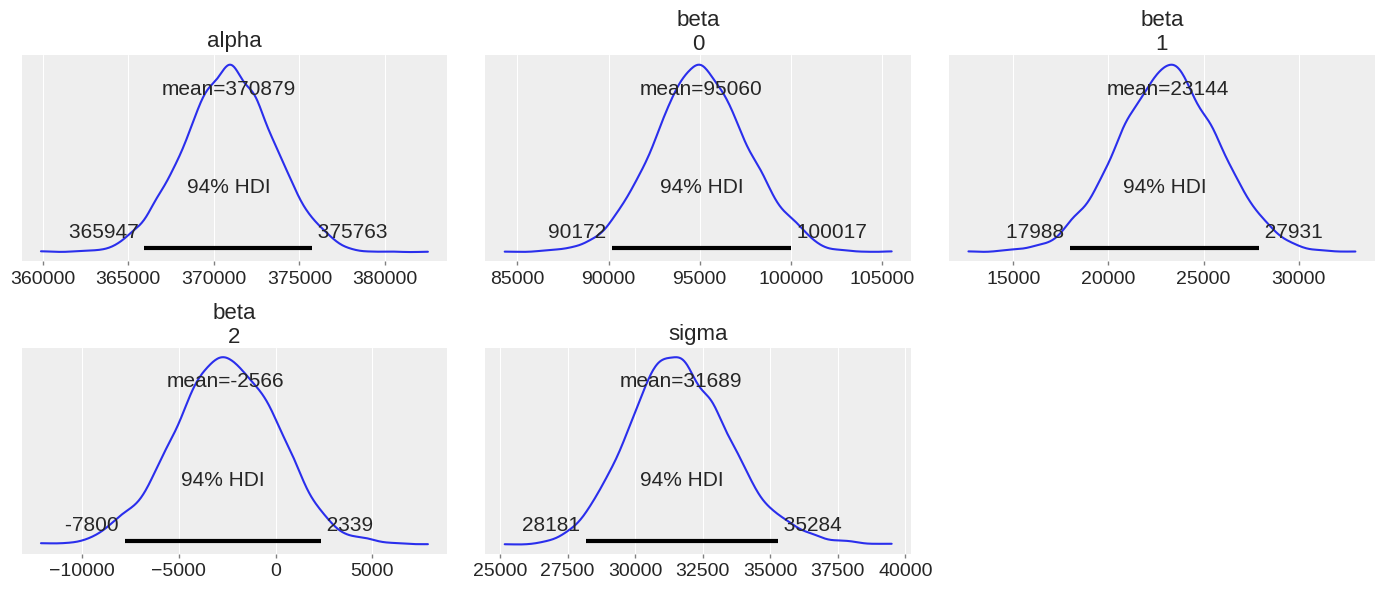


Posterior Summary:
               mean        sd      hdi_3%     hdi_97%  mcse_mean  mcse_sd  \
alpha    370878.690  2613.102  365947.289  375762.560     27.902   34.679   
beta[0]   95059.638  2609.351   90172.407  100017.256     24.725   33.315   
beta[1]   23143.760  2652.038   17988.456   27931.322     30.452   33.967   
beta[2]   -2566.130  2688.489   -7799.840    2339.220     26.512   34.420   
sigma     31688.983  1895.916   28181.085   35283.661     19.789   24.851   

         ess_bulk  ess_tail  r_hat  
alpha      8753.0    4458.0    1.0  
beta[0]   11164.0    4996.0    1.0  
beta[1]    7593.0    4802.0    1.0  
beta[2]   10283.0    5161.0    1.0  
sigma      9130.0    4613.0    1.0  


In [11]:
# Plot posteriors
az.plot_posterior(trace_multi, var_names=['alpha', 'beta', 'sigma'], figsize=(14, 6))
plt.tight_layout()
plt.show()

# Summary
print("\nPosterior Summary:")
print(az.summary(trace_multi, var_names=['alpha', 'beta', 'sigma']))

### Interpreting Multiple Regression Coefficients

Each $\beta_i$ represents the expected change in $Y$ for a one-unit change in $X_i$, **holding all other variables constant**.

Since we standardized, we need to convert back:

In [12]:
beta_samples = trace_multi.posterior['beta'].values
beta_original = beta_samples / X_std
beta_original.shape

(3, 2000, 3)

In [13]:
# Convert coefficients to original scale
beta_samples = trace_multi.posterior['beta'].values
beta_original = beta_samples / X_std

feature_names = ['Area', 'Bedrooms', 'Age']
true_betas = [true_beta_area, true_beta_bedrooms, true_beta_age]

print("Coefficient estimates (original scale):\n")
for i, name in enumerate(feature_names):
    beta_i = beta_original[:, :, i].flatten()
    print(f"{name}:")
    print(f"  Estimated: {beta_i.mean():.2f}")
    print(f"  True: {true_betas[i]:.2f}")
    print(f"  95% CI: [{np.percentile(beta_i, 2.5):.2f}, {np.percentile(beta_i, 97.5):.2f}]")
    print()

Coefficient estimates (original scale):

Area:
  Estimated: 146.20
  True: 150.00
  95% CI: [138.41, 154.16]

Bedrooms:
  Estimated: 16738.25
  True: 20000.00
  95% CI: [13009.62, 20467.78]

Age:
  Estimated: -173.68
  True: -500.00
  95% CI: [-541.13, 175.09]



### Posterior Predictive Checks
The infered posterior can be then used to predict the future samples. The accuracy can be checked by comparing some observed samples as the groundtruth and the output of the model.

Output()

/tmp/ipykernel_1287/1068222889.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


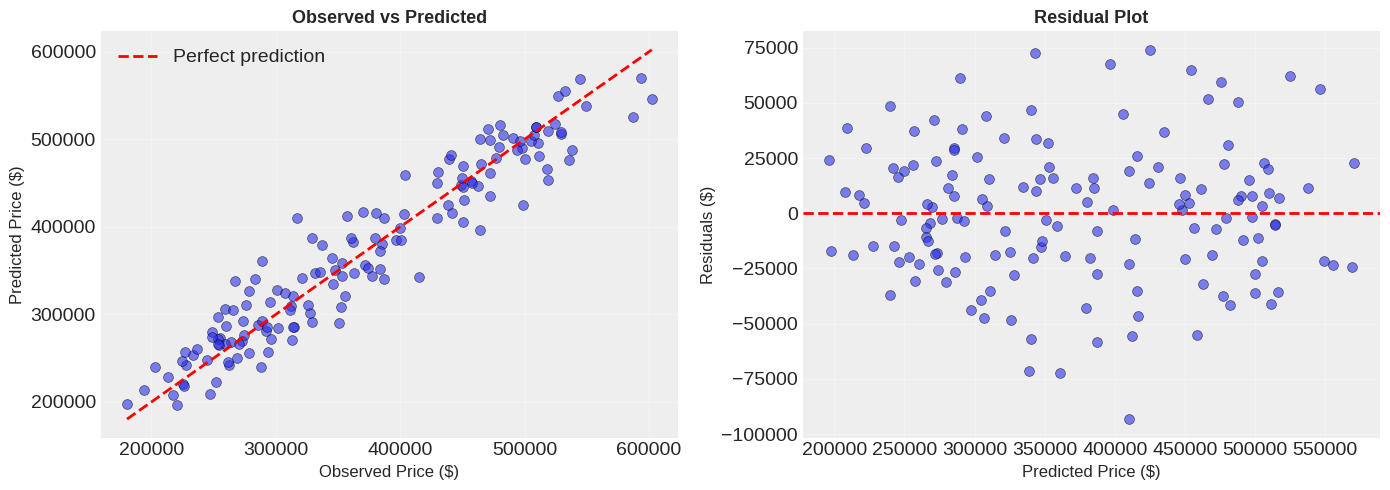


R² = 0.911


In [14]:
# Generate posterior predictive samples
with multi_model:
    ppc = pm.sample_posterior_predictive(trace_multi, random_seed=42)

# Plot observed vs predicted
y_pred = ppc.posterior_predictive['y_obs'].values.reshape(-1, len(price))
y_pred_mean = y_pred.mean(axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Observed vs Predicted
ax1.scatter(price, y_pred_mean, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax1.plot([price.min(), price.max()], [price.min(), price.max()],
         'r--', linewidth=2, label='Perfect prediction')
ax1.set_xlabel('Observed Price ($)', fontsize=12)
ax1.set_ylabel('Predicted Price ($)', fontsize=12)
ax1.set_title('Observed vs Predicted', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Residuals
residuals = price - y_pred_mean
ax2.scatter(y_pred_mean, residuals, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax2.axhline(0, color='r', linestyle='--', linewidth=2)
ax2.set_xlabel('Predicted Price ($)', fontsize=12)
ax2.set_ylabel('Residuals ($)', fontsize=12)
ax2.set_title('Residual Plot', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate R-squared
ss_res = np.sum(residuals**2)
ss_tot = np.sum((price - price.mean())**2)
r_squared = 1 - (ss_res / ss_tot)
print(f"\nR² = {r_squared:.3f}")

## Model Comparison

When we have multiple candidate models, how do we choose the best one?

**Two competing goals:**
1. **Fit:** Model should explain observed data well
2. **Simplicity:** Avoid overfitting (complex models fit noise)

**Information Criteria:** Balance fit and complexity

### WAIC: Widely Applicable Information Criterion

$$\text{WAIC} = -2(\text{lppd} - p_{\text{WAIC}})$$

where:
- **lppd** = log pointwise predictive density (fit quality)
- **p_WAIC** = effective number of parameters (complexity penalty)

**Lower WAIC = Better predictive performance**

### LOO-CV: Leave-One-Out Cross-Validation

**Idea:** How well does model predict unseen data?

- Leave out observation $i$
- Fit model to remaining data
- Predict left-out $y_i$
- Repeat for all observations

PyMC uses **Pareto Smoothed Importance Sampling (PSIS-LOO)** to approximate LOO without refitting.

**Higher eLPD (expected log predictive density) = Better**

### Comparing Models

**Decision rule:** $\quad |\Delta\text{WAIC}| > 2 \times \text{SE}$ → models differ significantly

Both WAIC and LOO should agree on ranking. If they disagree, investigate!

### Comparing Nested Models

Let's compare:
- **Model 1**: Only area
- **Model 2**: Area + bedrooms
- **Model 3**: Area + bedrooms + age (our full model)

In [15]:
# Model 1: Area only
X1 = X_standardized[:, 0:1]
with pm.Model() as model1:
    alpha = pm.Normal('alpha', mu=300000, sigma=100000)
    beta = pm.Normal('beta', mu=0, sigma=100000)
    sigma = pm.HalfNormal('sigma', sigma=50000)
    mu = alpha + beta * X1.flatten()
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=price)
    trace1 = pm.sample(2000, tune=1000, chains=3, random_seed=42, return_inferencedata=True, idata_kwargs={"log_likelihood": True})

# Model 2: Area + Bedrooms
X2 = X_standardized[:, 0:2]
with pm.Model() as model2:
    alpha = pm.Normal('alpha', mu=300000, sigma=100000)
    beta = pm.Normal('beta', mu=0, sigma=100000, shape=2)
    sigma = pm.HalfNormal('sigma', sigma=50000)
    mu = alpha + pm.math.dot(X2, beta)
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=price)
    trace2 = pm.sample(2000, tune=1000, chains=3, random_seed=42, return_inferencedata=True, idata_kwargs={"log_likelihood": True})

# Model 3: Area + Bedrooms + Age
X3 = X_standardized[:, 0:3]
with pm.Model() as model3:
    alpha = pm.Normal('alpha', mu=300000, sigma=100000)
    beta = pm.Normal('beta', mu=0, sigma=100000, shape=3)
    sigma = pm.HalfNormal('sigma', sigma=50000)
    mu = alpha + pm.math.dot(X3, beta)
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=price)
    trace3 = pm.sample(2000, tune=1000, chains=3, random_seed=42, return_inferencedata=True, idata_kwargs={"log_likelihood": True})

print("\nAll models sampled!")

Output()

Output()

Output()


All models sampled!


In [16]:
# Compare models using BOTH WAIC and LOO

# Compute WAIC for each model
waic1 = az.waic(trace1)
waic2 = az.waic(trace2)
waic3 = az.waic(trace3)


# Compute LOO for each model
loo1 = az.loo(trace1)
loo2 = az.loo(trace2)
loo3 = az.loo(trace3)

print("\n" + "="*70)
print("MODEL COMPARISON: WAIC")
print("="*70)
waic_comparison = az.compare({'Model 1 (Area)': trace1,
                              'Model 2 (Area+Bedrooms)': trace2,
                              'Model 3 (Area+Bedrooms+Age)': trace3},
                             ic='waic')
print(waic_comparison)

print("\n" + "="*70)
print("MODEL COMPARISON: LOO-CV")
print("="*70)
loo_comparison = az.compare({'Model 1 (Area)': trace1,
                             'Model 2 (Area+Bedrooms)': trace2,
                             'Model 3 (Area+Bedrooms+Age)': trace3},
                            ic='loo')
print(loo_comparison)

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)
print("WAIC (Widely Applicable Information Criterion):")
print(f"  Model 1: WAIC = {-2 * waic1.elpd_waic:.2f} \u00b1 {2 * waic1.se:.2f}")
print(f"  Model 2: WAIC = {-2 * waic2.elpd_waic:.2f} \u00b1 {2 * waic2.se:.2f}")
print(f"  Model 3: WAIC = {-2 * waic3.elpd_waic:.2f} \u00b1 {2 * waic3.se:.2f}")

print("\nLOO-CV (Leave-One-Out Cross-Validation):")
print(f"  Model 1: LOO = {loo1.elpd_loo:.2f} \u00b1 {loo1.se:.2f}")
print(f"  Model 2: LOO = {loo2.elpd_loo:.2f} \u00b1 {loo2.se:.2f}")
print(f"  Model 3: LOO = {loo3.elpd_loo:.2f} \u00b1 {loo3.se:.2f}")

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(



MODEL COMPARISON: WAIC
                             rank    elpd_waic    p_waic  elpd_diff  \
Model 2 (Area+Bedrooms)         0 -1768.510883  3.543055   0.000000   
Model 3 (Area+Bedrooms+Age)     1 -1769.287669  4.778552   0.776785   
Model 1 (Area)                  2 -1800.611670  2.648209  32.100787   

                                   weight        se       dse  warning scale  
Model 2 (Area+Bedrooms)      1.000000e+00  8.490154  0.000000    False   log  
Model 3 (Area+Bedrooms+Age)  2.775558e-16  8.751326  1.065707     True   log  
Model 1 (Area)               0.000000e+00  7.951319  6.815350    False   log  

MODEL COMPARISON: LOO-CV


/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


                             rank     elpd_loo     p_loo  elpd_diff  \
Model 2 (Area+Bedrooms)         0 -1768.517936  3.550108   0.000000   
Model 3 (Area+Bedrooms+Age)     1 -1769.304604  4.795488   0.786668   
Model 1 (Area)                  2 -1800.616778  2.653317  32.098842   

                                   weight        se       dse  warning scale  
Model 2 (Area+Bedrooms)      1.000000e+00  8.491102  0.000000    False   log  
Model 3 (Area+Bedrooms+Age)  2.220446e-16  8.754728  1.067703    False   log  
Model 1 (Area)               0.000000e+00  7.952229  6.816223    False   log  

INTERPRETATION
WAIC (Widely Applicable Information Criterion):
  Model 1: WAIC = 3601.22 ± 15.90
  Model 2: WAIC = 3537.02 ± 16.98
  Model 3: WAIC = 3538.58 ± 17.50

LOO-CV (Leave-One-Out Cross-Validation):
  Model 1: LOO = -1800.62 ± 7.95
  Model 2: LOO = -1768.52 ± 8.49
  Model 3: LOO = -1769.30 ± 8.75


/tmp/ipykernel_1287/2109254395.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


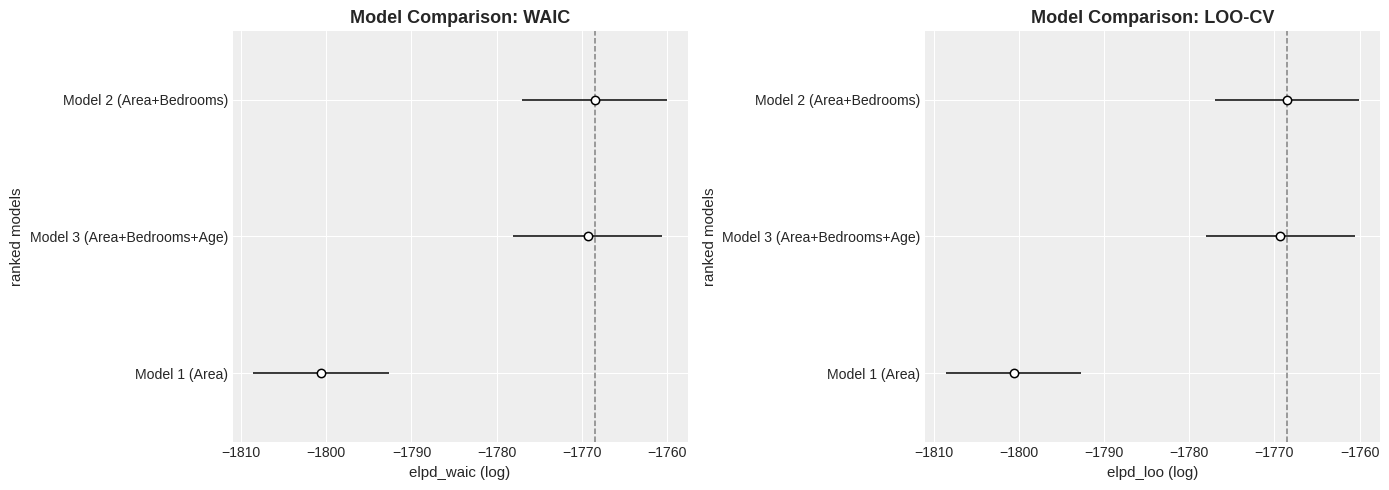


✓ Both WAIC and LOO agree: Model 2 (Area+Bedrooms) is better
✓ Adding bedrooms significantly improves predictive performance


In [17]:
# Visualize both WAIC and LOO comparisons
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# WAIC comparison
az.plot_compare(waic_comparison, ax=axes[0])
axes[0].set_title('Model Comparison: WAIC', fontsize=13, fontweight='bold')

# LOO comparison
az.plot_compare(loo_comparison, ax=axes[1])
axes[1].set_title('Model Comparison: LOO-CV', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Both WAIC and LOO agree: Model 2 (Area+Bedrooms) is better")
print("✓ Adding bedrooms significantly improves predictive performance")

### Exercise 1
Build a simple linear regression model for the housing data using only `age` as predictor. Compare it to the full model using LOO.

In [18]:
# Your code here

### Exercise 2
Generate posterior predictive samples for a new house with:
- Area: 2000 sq ft
- Bedrooms: 3
- Age: 10 years

What is the predicted price and its 95% credible interval?

In [19]:
# Your code here

### Exercise 3
Create a model with an interaction term between `area` and `bedrooms`. Does this improve the model according to LOO?

In [20]:
# Your code here